#### 移動の無駄と停滞エリアの比較

* どこで時間を消費しているか？
* 農家や労働者がどこで最も時間を消費しているか？

#### 特徴量

`["farmer_x_y"]` 自分の座標<br>
`["hands_list_1"]` 労働者1座標<br>
.<br>
.<br>
`["hands_list_20"]` 労働者20座標<br>
`["unlocked_quadrants"]` アンロックした土地<br>

#### グラフ

* 2Dヒートマップ (2D Heatmap)
* ヒストグラム

**classfile**:
`kaggriculture_df.py`
`my_plot.py`

In [1]:
!unzip -qo /content/output_re.zip -d /data

In [2]:
import pandas as pd
from kaggriculture_df import Kaggriculture_df
from my_plot import sns_Hist
import ast
from numpy import astype
import plotly.express as px

#1
def convert(val):
    """
    文字列の "[4, 4]" などを、リストの [4, 4] に変換

    """
    if isinstance(val, str):
        return ast.literal_eval(val)
    else:
        return val


import seaborn as sns
import matplotlib.pyplot as plt
import math


#2
def xy_plt_2d(df):
    """
    df[""]をヒートマップに変換：単体

    <df>:2D配列のdf[x,y]
    """
    df = df.apply(convert)
    df_xy = pd.DataFrame(df.tolist(), columns=["x", "y"])
    df_xy = df_xy.dropna().astype(int)
    heatmap_data = pd.crosstab(df_xy['y'], df_xy['x'])
    grid_range = list(range(10))
    heatmap_data = heatmap_data.reindex(
        index=grid_range, columns=grid_range, fill_value=0
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
    plt.show()


#3
def xy_plt_2d_all(df, cols, n_rows, n_cols):
    """
    df[""]をヒートマップに変換：複数

    <df>:2D配列のdf[x,y]

    xy_plt_2d_all(df_st, ["<列>", "<列>"], <行の数>, <列の数>)
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()

    grid_range = list(range(10))

    for i, col in enumerate(cols):
        ax = axes[i]

        s = df[col].apply(convert)
        df_xy = pd.DataFrame(s.tolist(), columns=["x", "y"])
        df_xy = df_xy.dropna().astype(int)
        heatmap_data = pd.crosstab(df_xy['y'], df_xy['x'])

        heatmap_data = heatmap_data.reindex(
            index=grid_range, columns=grid_range, fill_value=0
        )



        sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d", ax=ax, cbar=False)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

#4
def create_all_hands_feature(df):
    """
    ["hands_list_1"] 〜 ["hands_list_20"] を合算し、
    "all_hands" 列を作成する。
    """
    hands_cols = [f"hands_list_{i}" for i in range(1, 21)]

    def agg_hands(row):
        combined = []
        for col in hands_cols:
            if col in row.index:
                val = row[col]
                if isinstance(val, (str, list)):
                    val = convert(val)
                    if isinstance(val, list) and len(val) == 2:
                        combined.append(val)
        return combined

    df["all_hands"] = df.apply(agg_hands, axis=1)
    return df


#5
def new_xy_plt_2d(df):
    """
    df[""]をヒートマップに変換：複数座標の合算専用

    <df>: 複数座標のdf[[x,y], [x,y]...] (例: all_hands)
    """
    all_coords = []

    for val in df:
        val = convert(val)
        if isinstance(val, list) and len(val) > 0 and isinstance(val[0], list):
            all_coords.extend(val)

    df_xy = pd.DataFrame(all_coords, columns=["x", "y"])
    df_xy = df_xy.dropna().astype(int)
    heatmap_data = pd.crosstab(df_xy['y'], df_xy['x'])
    grid_range = list(range(10))
    heatmap_data = heatmap_data.reindex(
        index=grid_range, columns=grid_range, fill_value=0
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
    plt.show()



df_st = (Kaggriculture_df("/data/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/data/be_data/beginner_rank1_score99661.0_p1.json",1)).df

In [3]:
df_st

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,144726.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,146959.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,156142.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,157185.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]


In [4]:
df_be

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,91747.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,93457.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,98093.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,99229.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]


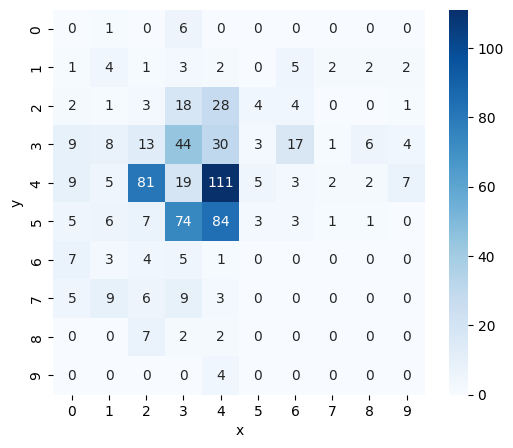

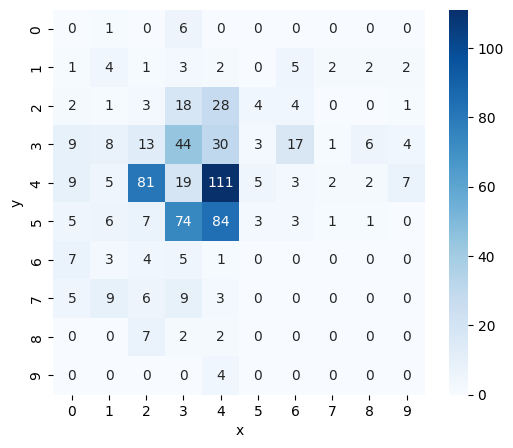

In [5]:
xy_plt_2d(df_st["farmer_x_y"])
xy_plt_2d(df_be["farmer_x_y"])

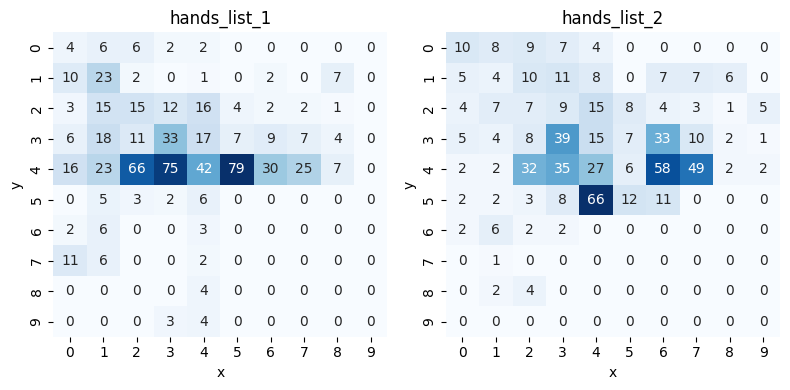

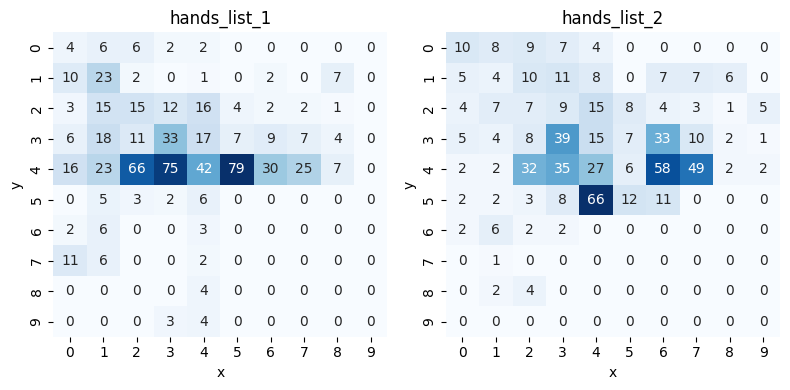

In [6]:
xy_plt_2d_all(df_st, ["hands_list_1", "hands_list_2"], 1, 2)
xy_plt_2d_all(df_be, ["hands_list_1", "hands_list_2"], 1, 2)

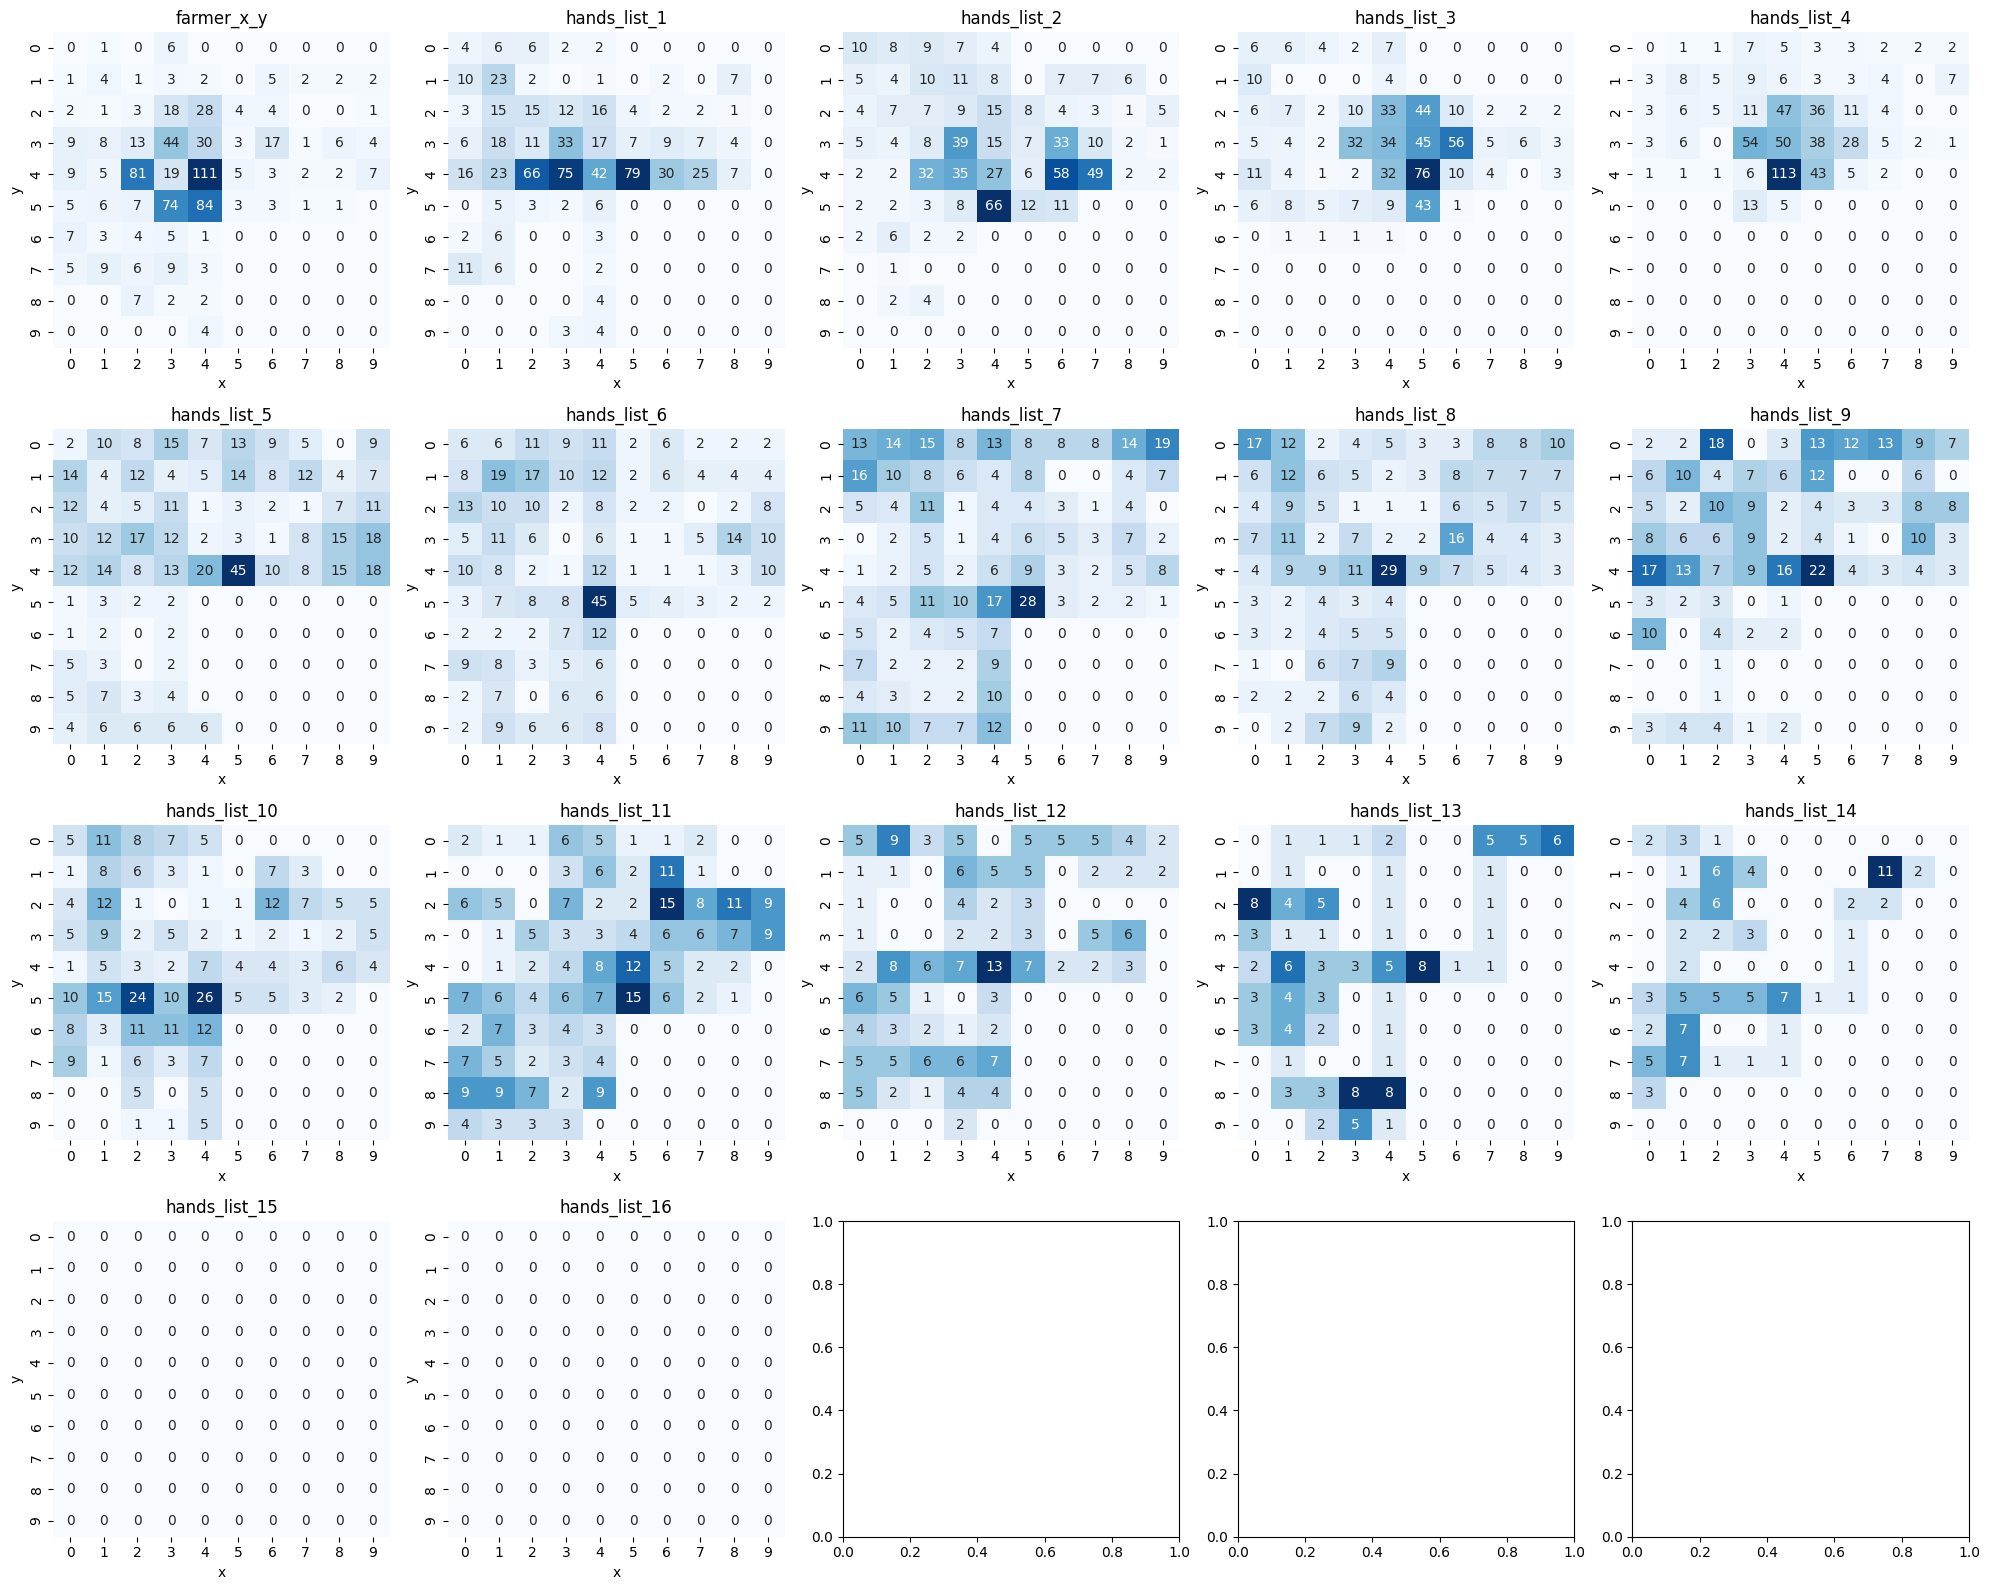

In [7]:
cols_st = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_st, cols_st, 4, 5)

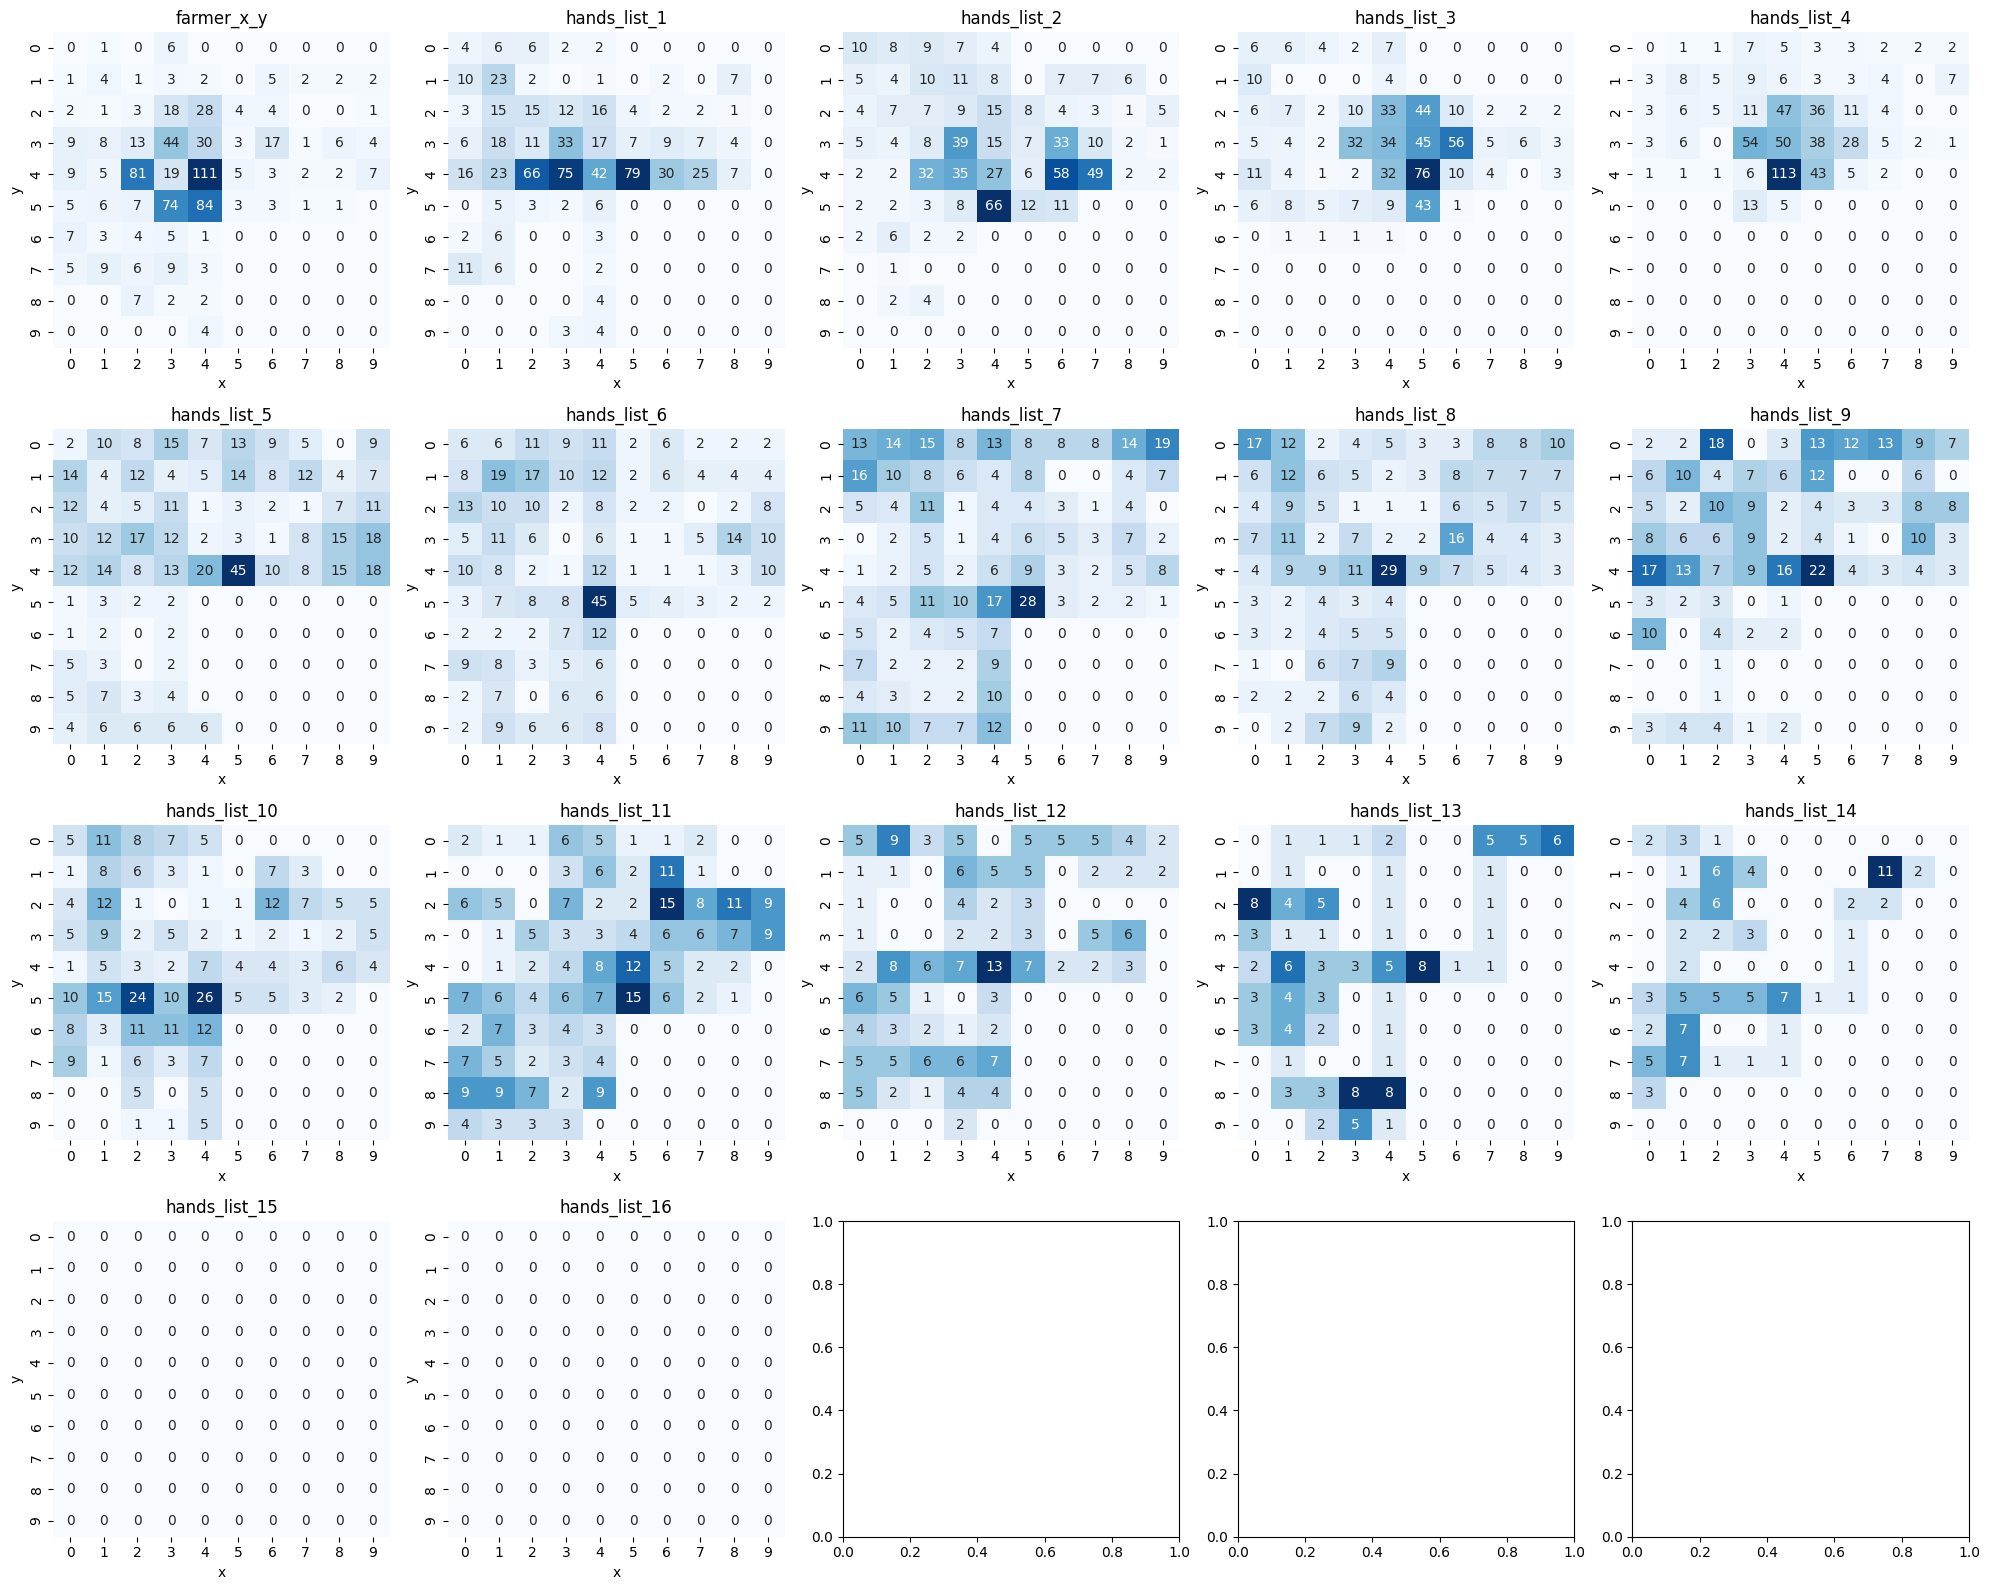

In [8]:
cols_be = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_be, cols_be, 4, 5)

### 従業員達の総合的な動き

* 中心に近いマスであればあるほど値が大きいことに気が付きました。


In [9]:
df_st = create_all_hands_feature(df_st)
df_be = create_all_hands_feature(df_be)
df_st["all_hands"][0]

[[None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None],
 [None, None]]

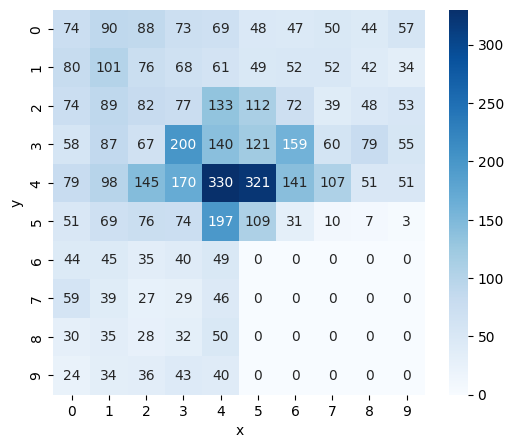

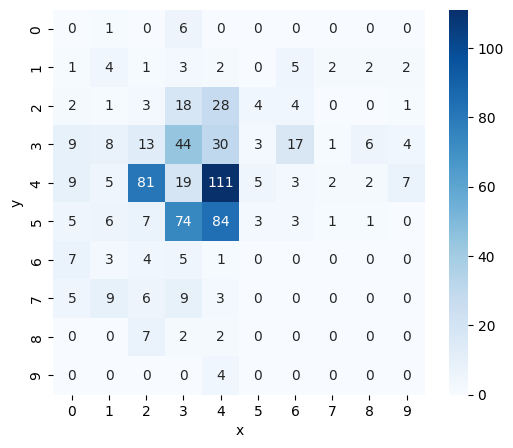

In [10]:
new_xy_plt_2d(df_st["all_hands"])
xy_plt_2d(df_st["farmer_x_y"])

# 土地をアンロックしたタイミング（２データ共通）

* ２つのデータを比較して結果
  全く同じデータだということがわかりました。


In [11]:
test1 = df_st["unlocked_quadrants"].equals(df_be["unlocked_quadrants"])
test2 = df_st["money"].equals(df_be["money"])

print(f"df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: {test1}")
print(f"df_st[money]とdf_be[money]のデータは完全に同じか？: {test2}")

df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: True
df_st[money]とdf_be[money]のデータは完全に同じか？: False


In [12]:
df_st["unlocked_quadrants"].value_counts()

,count
unlocked_quadrants,
"[NW, NE, SW]",455
[NW],169
"[NW, NE]",96


In [13]:
df_be["unlocked_quadrants"].value_counts()

,count
unlocked_quadrants,
"[NW, NE, SW]",455
[NW],169
"[NW, NE]",96


最適な同じノートブック、ロジックをみんなで共有している可能性

### 可視化するヒストグラム
* 土地をアンロックしたタイミング
* これらも全て同じ動き
* 動きについては最適な動きであり、皆がこの動きに終点したのか？

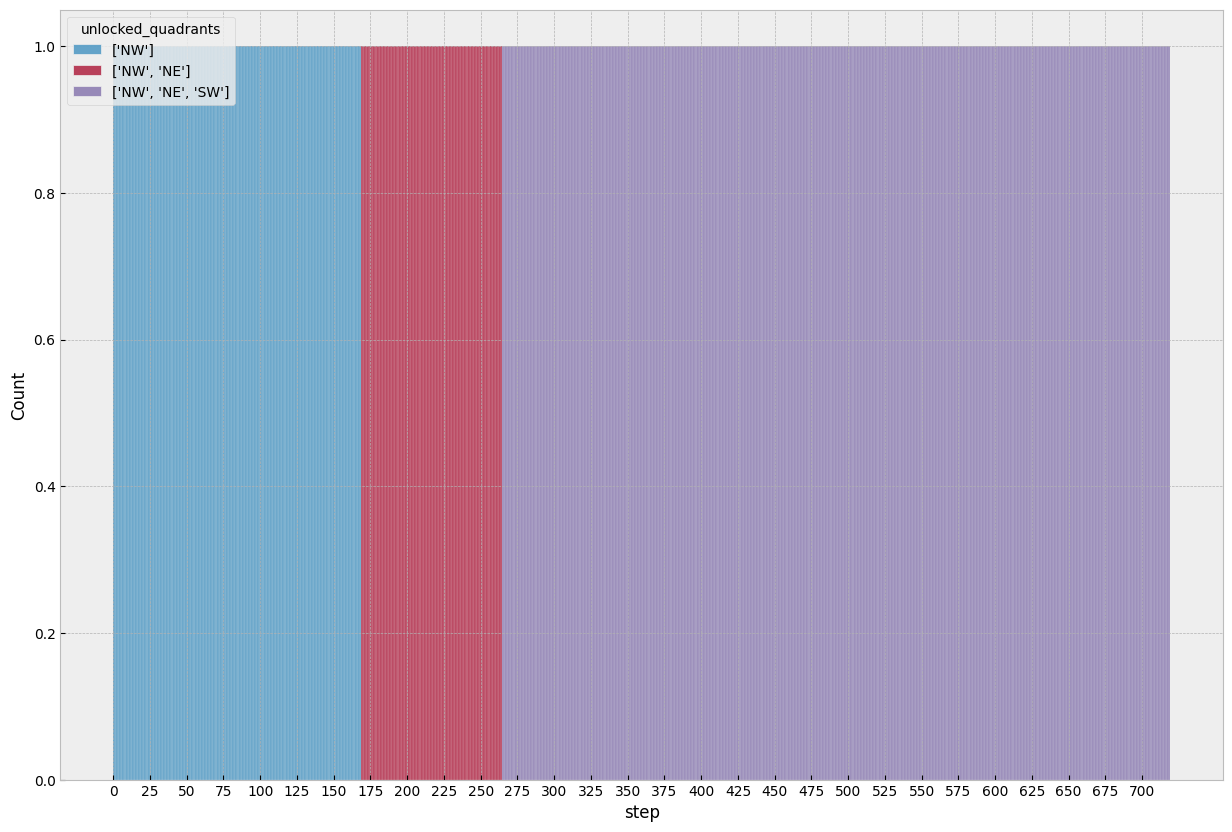

In [14]:
df_st_unlock = df_st[["step", "unlocked_quadrants"]].copy()
df_st_unlock["unlocked_quadrants"] = df_st_unlock["unlocked_quadrants"].astype(str)
sns_Hist(data=df_st_unlock, x="step", hue="unlocked_quadrants", figsize=(15,10), step=25, bins=720)

### この章で理解した事

* 主はほとんど動いていない、常に[4, 4]の近くにいる。
* そしてそれぞれに役割のポジションがある。



`メモ`


#### [jp_readme.md](https://github.com/kenkenkengo0421/Kaggriculture/blob/main/data/jp_readme.md)←ルールブック参照元

1. マップの中心部付近[4, 4]で出来る事

* 物置（Shed）の利用: $[4, 4]$ 自体が物置の設置場所です。直交隣接または同じマスにいることで、アイテムの取り出し（PICKUP）、投入・移動（DROP / PLACE）ができます。

* スポーン（出現）: 農家および雇われた労働者は、毎日の開始時に物置の場所（またはその隣接マス）からスポーンします。

* 一日の終わりの自動納品: 一日の終わりに、農家や労働者がインベントリに保持しているアイテムは自動的に物置へ移動されます（100個の容量オーバー分は破棄）。

2. 農家 "farmer" にしかできないことはない

3. 売買はどこでもできる

